<a href="https://colab.research.google.com/github/Harshactinium07/ML-Assignment/blob/main/Assignment-ML-LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import numpy as np
import random
import sys

# set all random seeds to 42
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Checks GPU
gpu_available = torch.cuda.is_available()

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("NumPy version:", np.__version__)
print("GPU available:", gpu_available)

if gpu_available:
    print("GPU Name:", torch.cuda.get_device_name(0))

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch version: 2.10.0+cu128
NumPy version: 2.0.2
GPU available: True
GPU Name: Tesla T4


In [ ]:
from torchvision import datasets
import numpy as np

# Load datasets
mnist_train = datasets.MNIST(root='./data', train=True, download=True)
mnist_test = datasets.MNIST(root='./data', train=False, download=True)

cifar_train = datasets.CIFAR10(root='./data', train=True, download=True)
cifar_test = datasets.CIFAR10(root='./data', train=False, download=True)

# Convert to numpy
mnist_data = mnist_train.data.numpy()
cifar_data = np.array(cifar_train.data)

# Shapes
print("MNIST Train Shape:", mnist_data.shape)
print("MNIST Test Shape:", mnist_test.data.shape)

print("CIFAR Train Shape:", cifar_data.shape)
print("CIFAR Test Shape:", np.array(cifar_test.data).shape)

# Data type & range
print("\nMNIST dtype:", mnist_data.dtype)
print("MNIST range:", mnist_data.min(), "to", mnist_data.max())

print("\nCIFAR dtype:", cifar_data.dtype)
print("CIFAR range:", cifar_data.min(), "to", cifar_data.max())

# Classes
print("\nMNIST classes: 10 (digits 0-9)")
print("CIFAR-10 classes:", cifar_train.classes)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.08MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.8MB/s]
100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: torch.Size([10000, 28, 28])
CIFAR Train Shape: (50000, 32, 32, 3)
CIFAR Test Shape: (10000, 32, 32, 3)

MNIST dtype: uint8
MNIST range: 0 to 255

CIFAR dtype: uint8
CIFAR range: 0 to 255

MNIST classes: 10 (digits 0-9)
CIFAR-10 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


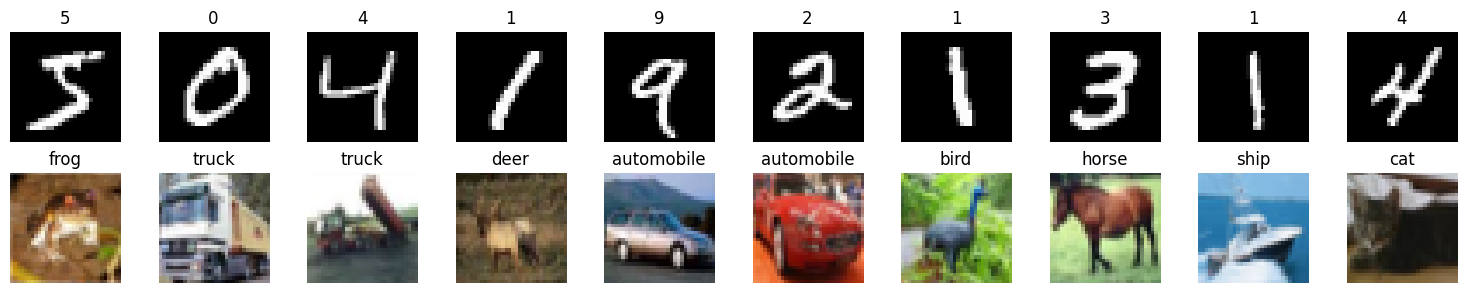

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 10, figsize=(15, 3))

# MNIST
for i in range(10):
    axes[0, i].imshow(mnist_train.data[i], cmap='gray')
    axes[0, i].set_title(mnist_train.targets[i].item())
    axes[0, i].axis('off')

# CIFAR
for i in range(10):
    axes[1, i].imshow(cifar_train.data[i])
    axes[1, i].set_title(cifar_train.classes[cifar_train.targets[i]])
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

In [ ]:
import numpy as np

def preprocess_images(images, labels):

    print("----- BEFORE PROCESSING -----")
    print("Shape:", images.shape)
    print("Dtype:", images.dtype)
    print("Range:", images.min(), "to", images.max())
    print("Sample label:", labels[0])

    # (a) Normalize (convert to float first!)
    images = images.astype(np.float32) / 255.0

    print("\n----- AFTER NORMALIZATION -----")
    print("Dtype:", images.dtype)
    print("Range:", images.min(), "to", images.max())

    # (b) Add channel dimension (for MNIST)
    if len(images.shape) == 3:  # (N, 28, 28)
        images = np.expand_dims(images, axis=-1)

    print("\n----- AFTER RESHAPING -----")
    print("New Shape:", images.shape)

    # (c) One-hot encoding
    num_classes = 10
    one_hot_labels = np.zeros((labels.shape[0], num_classes))
    one_hot_labels[np.arange(labels.shape[0]), labels] = 1

    print("\n----- AFTER ONE-HOT ENCODING -----")
    print("Label shape:", one_hot_labels.shape)
    print("Sample one-hot label:", one_hot_labels[0])

    return images, one_hot_labels

In [ ]:
mnist_images = mnist_train.data.numpy()
mnist_labels = mnist_train.targets.numpy()

processed_images, processed_labels = preprocess_images(mnist_images, mnist_labels)

----- BEFORE PROCESSING -----
Shape: (60000, 28, 28)
Dtype: uint8
Range: 0 to 255
Sample label: 5

----- AFTER NORMALIZATION -----
Dtype: float32
Range: 0.0 to 1.0

----- AFTER RESHAPING -----
New Shape: (60000, 28, 28, 1)

----- AFTER ONE-HOT ENCODING -----
Label shape: (60000, 10)
Sample one-hot label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


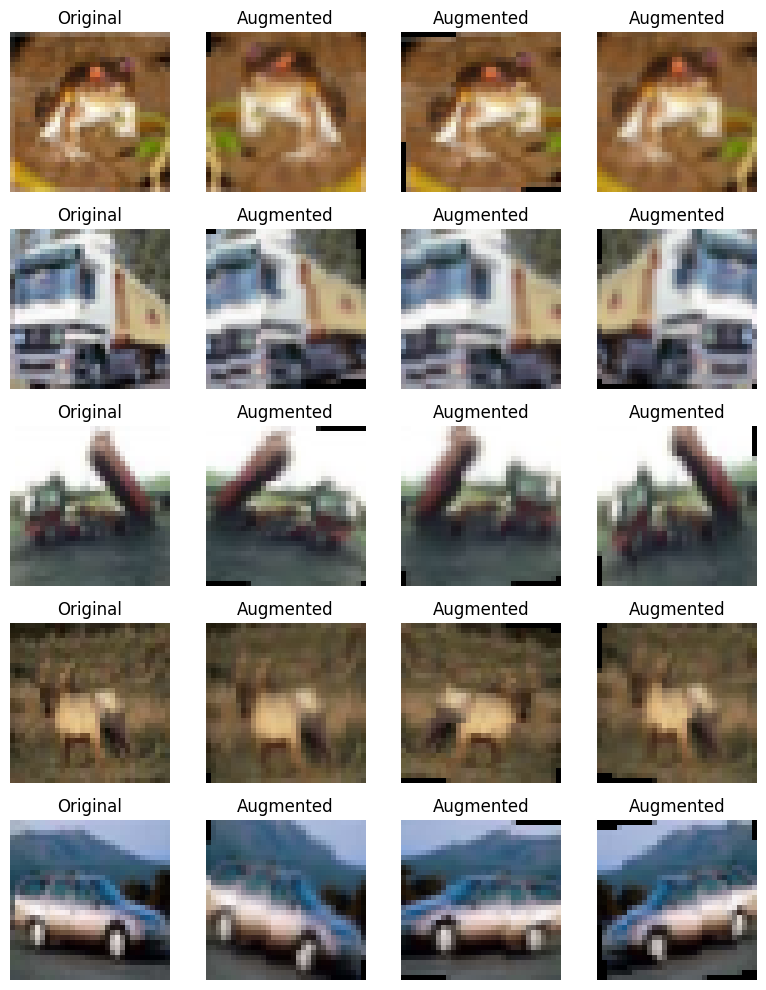

In [ ]:
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Define augmentation pipeline
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(size=32, scale=(0.8, 1.0)),
    transforms.ToTensor()
])

# Get 5 CIFAR images
images = cifar_train.data[:5]
labels = cifar_train.targets[:5]

fig, axes = plt.subplots(5, 4, figsize=(8, 10))

for i in range(5):
    original = images[i]

    # Column 1 → original
    axes[i, 0].imshow(original)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')

    # 3 augmented versions
    for j in range(1, 4):
        aug_img = transform(original)
        aug_img = aug_img.permute(1, 2, 0).numpy()

        axes[i, j].imshow(aug_img)
        axes[i, j].set_title("Augmented")
        axes[i, j].axis('off')

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()

In [ ]:
import numpy as np

def conv2d(image, kernel, stride=1, padding=0):

    # Get dimensions
    H, W = image.shape
    kH, kW = kernel.shape

    # Add padding
    if padding > 0:
        padded = np.zeros((H + 2*padding, W + 2*padding))
        padded[padding:padding+H, padding:padding+W] = image
    else:
        padded = image.copy()

    # Output size
    out_H = (padded.shape[0] - kH) // stride + 1
    out_W = (padded.shape[1] - kW) // stride + 1

    output = np.zeros((out_H, out_W))

    # Convolution operation
    for i in range(out_H):
        for j in range(out_W):
            region = padded[i*stride:i*stride+kH, j*stride:j*stride+kW]
            output[i, j] = np.sum(region * kernel)

    return output

In [ ]:
image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,2,2,1,0]
])

kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

output = conv2d(image, kernel, stride=1, padding=0)
print(output)
print("Output shape:", output.shape)

[[-5.  0.  1.]
 [-7. -1.  4.]
 [-6. -3.  4.]]
Output shape: (3, 3)


In [ ]:
import torch
import torch.nn as nn

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()

        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)

        self.fc1 = nn.Linear(16*4*4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.conv1(x))
        x = self.pool(x)

        x = self.tanh(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.fc3(x)

        return x

In [ ]:
model = LeNet5()
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

Total parameters: 44426


In [ ]:
import torch
import torch.nn as nn

class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        self.gap = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 800),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

In [ ]:
model = CustomCNN()
print(sum(p.numel() for p in model.parameters()))

202026


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load MNIST
dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

# Split (90% train, 10% val)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64)

# Model
model = LeNet5().to(device)

# Loss + Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Tracking
train_losses, val_losses = [], []
train_accs, val_accs = [], []

# Training loop
for epoch in range(15):
    model.train()
    total_loss, correct = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    train_loss = total_loss / len(train_loader)
    train_acc = correct / len(train_dataset)

    # Validation
    model.eval()
    val_loss, correct = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            val_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = correct / len(val_dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

Epoch 1: Train Loss=2.0763, Val Loss=1.3579
Epoch 2: Train Loss=0.8055, Val Loss=0.5442
Epoch 3: Train Loss=0.4593, Val Loss=0.4116
Epoch 4: Train Loss=0.3714, Val Loss=0.3502
Epoch 5: Train Loss=0.3210, Val Loss=0.3067
Epoch 6: Train Loss=0.2818, Val Loss=0.2712
Epoch 7: Train Loss=0.2490, Val Loss=0.2407
Epoch 8: Train Loss=0.2205, Val Loss=0.2139
Epoch 9: Train Loss=0.1963, Val Loss=0.1891
Epoch 10: Train Loss=0.1757, Val Loss=0.1715
Epoch 11: Train Loss=0.1586, Val Loss=0.1561
Epoch 12: Train Loss=0.1446, Val Loss=0.1414
Epoch 13: Train Loss=0.1327, Val Loss=0.1314
Epoch 14: Train Loss=0.1228, Val Loss=0.1217
Epoch 15: Train Loss=0.1140, Val Loss=0.1144


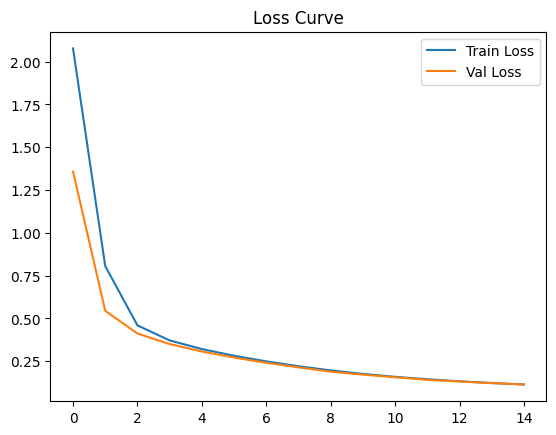

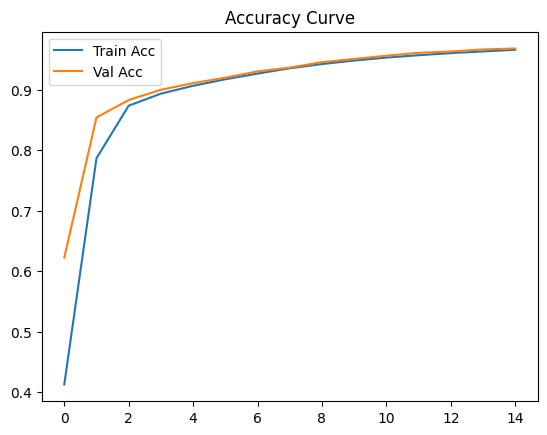

In [ ]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.savefig("lenet_sgd_curves.png")
plt.show()

plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [ ]:
model.eval()
correct = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        correct += (outputs.argmax(1) == labels).sum().item()

test_acc = correct / len(test_dataset)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.9711


In [ ]:
def train_model(optimizer_name):
    model = LeNet5().to(device)

    if optimizer_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    elif optimizer_name == "momentum":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    criterion = nn.CrossEntropyLoss()

    val_accs = []

    for epoch in range(15):
        model.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Validation accuracy
        model.eval()
        correct = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = correct / len(val_dataset)
        val_accs.append(val_acc)

    return val_accs

In [ ]:
sgd_acc = train_model("sgd")
momentum_acc = train_model("momentum")
adam_acc = train_model("adam")

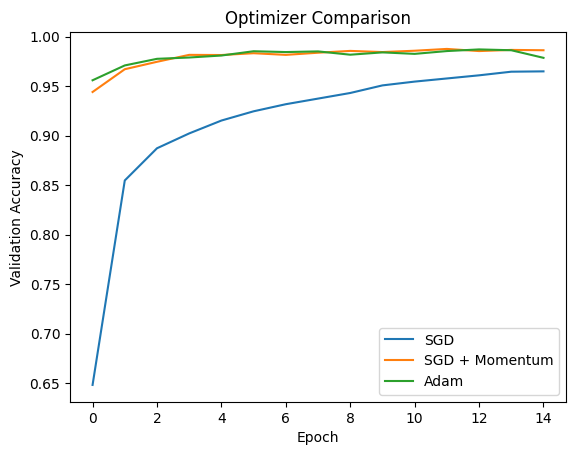

In [ ]:
import matplotlib.pyplot as plt

plt.plot(sgd_acc, label="SGD")
plt.plot(momentum_acc, label="SGD + Momentum")
plt.plot(adam_acc, label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Optimizer Comparison")
plt.legend()

plt.savefig("optimiser_comparison.png")
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load CIFAR-10
dataset = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)

# Split (90% train, 10% val)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

#  Your Custom CNN (same as before)
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        self.gap = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 800),  # tuned layer
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(800, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

#  Training function
def train_once(lr, batch_size):
    model = CustomCNN().to(device)  # fresh model every time

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # Train 10 epochs
    for epoch in range(10):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Validation accuracy
    model.eval()
    correct = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            correct += (outputs.argmax(1) == labels).sum().item()

    return correct / len(val_dataset)

lrs = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

results = {}

for lr in lrs:
    for bs in batch_sizes:
        acc = train_once(lr, bs)
        results[(lr, bs)] = acc
        print(f"LR={lr}, BS={bs} → Accuracy={acc:.4f}")

100%|██████████| 170M/170M [00:17<00:00, 9.49MB/s]


LR=0.1, BS=32 → Accuracy=0.0996
LR=0.1, BS=128 → Accuracy=0.1060
LR=0.01, BS=32 → Accuracy=0.7724
LR=0.01, BS=128 → Accuracy=0.6602
LR=0.001, BS=32 → Accuracy=0.7392
LR=0.001, BS=128 → Accuracy=0.6918


Epoch 1: Train=0.4562, Val=0.5602
Epoch 2: Train=0.5909, Val=0.6048
Epoch 3: Train=0.6478, Val=0.6464
Epoch 4: Train=0.6838, Val=0.6756
Epoch 5: Train=0.7120, Val=0.6876
Epoch 6: Train=0.7344, Val=0.6926
Epoch 7: Train=0.7569, Val=0.6856
Epoch 8: Train=0.7767, Val=0.6956
Epoch 9: Train=0.7987, Val=0.7116
Epoch 10: Train=0.8159, Val=0.6926
Epoch 11: Train=0.8320, Val=0.7126
Epoch 12: Train=0.8514, Val=0.7050
Epoch 13: Train=0.8688, Val=0.7104
Epoch 14: Train=0.8823, Val=0.7138
Epoch 15: Train=0.8965, Val=0.7052
Epoch 16: Train=0.9085, Val=0.7106
Epoch 17: Train=0.9228, Val=0.7036
Epoch 18: Train=0.9321, Val=0.7008
Epoch 19: Train=0.9434, Val=0.6956
Epoch 20: Train=0.9441, Val=0.7004
Epoch 1: Train=0.3393, Val=0.4764
Epoch 2: Train=0.4521, Val=0.5226
Epoch 3: Train=0.4902, Val=0.5790
Epoch 4: Train=0.5185, Val=0.5930
Epoch 5: Train=0.5368, Val=0.6164
Epoch 6: Train=0.5549, Val=0.6252
Epoch 7: Train=0.5658, Val=0.6428
Epoch 8: Train=0.5786, Val=0.6620
Epoch 9: Train=0.5857, Val=0.6610
Epo

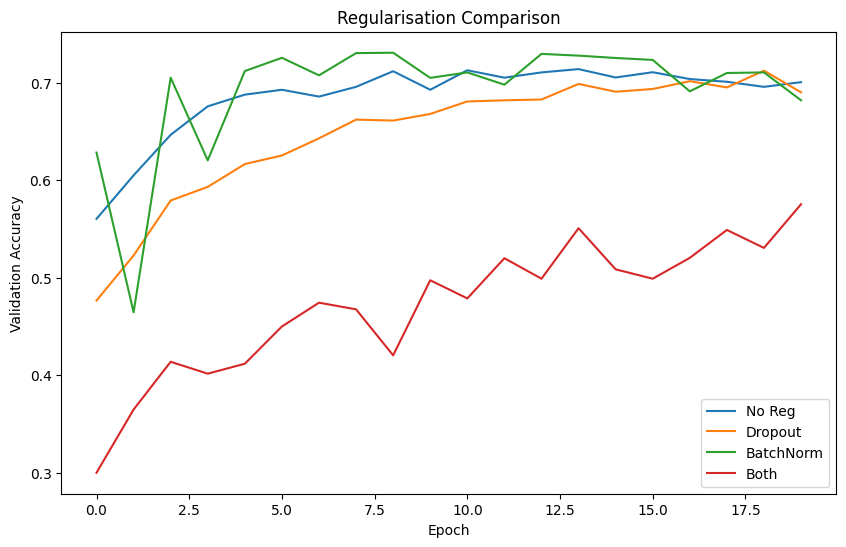


Final Train-Val Gaps:

No Reg: Gap = 0.2437
Dropout: Gap = -0.0514
BatchNorm: Gap = 0.2707
Both: Gap = -0.2085


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load CIFAR-10
dataset = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)

# Split dataset
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

# Model
class SimpleCNN(nn.Module):
    def __init__(self, use_bn=False, use_dropout=False):
        super(SimpleCNN, self).__init__()

        layers = []

        # Block 1
        layers.append(nn.Conv2d(3, 32, 3, padding=1))
        if use_bn:
            layers.append(nn.BatchNorm2d(32))
        layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(2))
        if use_dropout:
            layers.append(nn.Dropout(0.3))

        # Block 2
        layers.append(nn.Conv2d(32, 64, 3, padding=1))
        if use_bn:
            layers.append(nn.BatchNorm2d(64))
        layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(2))
        if use_dropout:
            layers.append(nn.Dropout(0.3))

        self.features = nn.Sequential(*layers)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 128),
            nn.ReLU(),
            nn.Dropout(0.5) if use_dropout else nn.Identity(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Training function
def train_model(use_bn, use_dropout):
    model = SimpleCNN(use_bn, use_dropout).to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    train_accs, val_accs = [], []

    for epoch in range(20):
        model.train()
        correct = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = correct / len(train_dataset)

        # Validation
        model.eval()
        correct = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = correct / len(val_dataset)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: Train={train_acc:.4f}, Val={val_acc:.4f}")

    return train_accs, val_accs


# Run all 4 variants
results = {}

results["No Reg"] = train_model(False, False)
results["Dropout"] = train_model(False, True)
results["BatchNorm"] = train_model(True, False)
results["Both"] = train_model(True, True)


# Plot results
plt.figure(figsize=(10,6))

for name, (train_acc, val_acc) in results.items():
    plt.plot(val_acc, label=f"{name}")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Regularisation Comparison")
plt.legend()
plt.savefig("regularisation_comparison.png")
plt.show()


# Compute gaps
print("\nFinal Train-Val Gaps:\n")

for name, (train_acc, val_acc) in results.items():
    gap = train_acc[-1] - val_acc[-1]
    print(f"{name}: Gap = {gap:.4f}")

In [ ]:
import torch.optim as optim

def train_with_scheduler(scheduler_type):
    model = SimpleCNN(use_bn=True, use_dropout=True).to(device)  # best model

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    if scheduler_type == "plateau":
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3
        )
    elif scheduler_type == "cosine":
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=30
        )

    val_accs = []
    lrs = []

    for epoch in range(30):
        model.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        correct = 0
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                loss = criterion(outputs, labels)
                val_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = correct / len(val_dataset)
        val_accs.append(val_acc)

        # Step scheduler
        if scheduler_type == "plateau":
            scheduler.step(val_loss)
        else:
            scheduler.step()

        # Store LR
        lrs.append(optimizer.param_groups[0]['lr'])

    return val_accs, lrs

In [ ]:
plateau_acc, plateau_lr = train_with_scheduler("plateau")
cosine_acc, cosine_lr = train_with_scheduler("cosine")

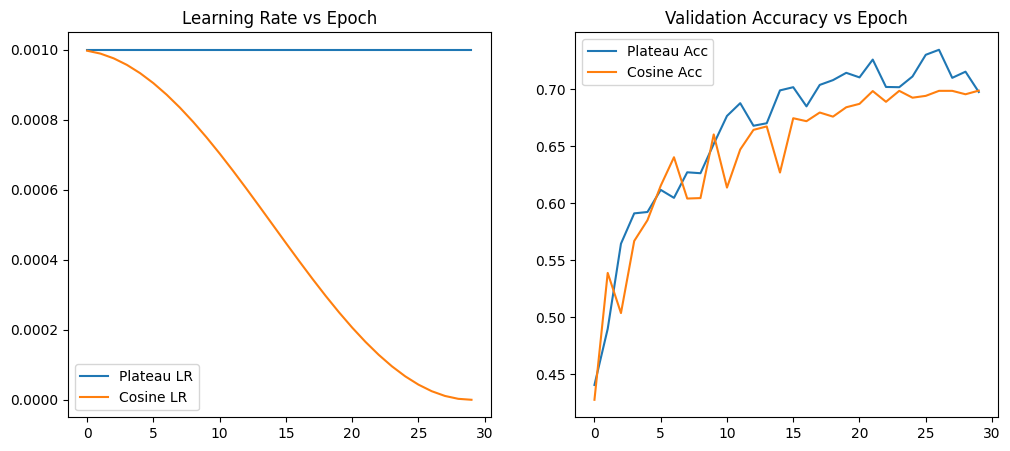

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# LR plot
plt.subplot(1,2,1)
plt.plot(plateau_lr, label="Plateau LR")
plt.plot(cosine_lr, label="Cosine LR")
plt.title("Learning Rate vs Epoch")
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(plateau_acc, label="Plateau Acc")
plt.plot(cosine_acc, label="Cosine Acc")
plt.title("Validation Accuracy vs Epoch")
plt.legend()

plt.savefig("lr_schedule_comparison.png")
plt.show()